In [35]:
#import libraries

import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import scipy.stats as stats

In [51]:
##PUNTO 1
#scarico i 6 ETF nel periodo di interesse

start = datetime.datetime(2016, 3, 31)
end = datetime.datetime(2026, 3, 31)
tickers = ['XLF', 'XLK', 'XLV', 'XLE', 'XLI', 'XLY', '^GSPC']

data = yf.download(tickers, start=start, end=end)
data=data.rename(columns={'^GSPC': 'SP500'})
print(data.head())

SP500 = yf.download('^GSPC', start, end)
SP500 = SP500.xs('^GSPC', axis=1, level = 'Ticker', drop_level=True)

XLF = yf.download('XLF', start, end)
XLF = XLF.xs('XLF', axis=1, level = 'Ticker', drop_level=True)
XLK = yf.download('XLK', start, end)
XLK = XLK.xs('XLK', axis=1, level = 'Ticker', drop_level=True)
XLV = yf.download('XLV', start, end)
XLV = XLV.xs('XLV', axis=1, level = 'Ticker', drop_level=True)
XLE = yf.download('XLE', start, end)
XLE = XLE.xs('XLE', axis=1, level = 'Ticker', drop_level=True)
XLI = yf.download('XLI', start, end)
XLI = XLI.xs('XLI', axis=1, level = 'Ticker', drop_level=True)
XLY = yf.download('XLY', start, end)
XLY = XLY.xs('XLY', axis=1, level = 'Ticker', drop_level=True)

[*********************100%***********************]  7 of 7 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price           Close                                                         \
Ticker            XLE        XLF        XLI        XLK        XLV        XLY   
Date                                                                           
2016-03-31  20.628201  15.161463  46.560280  19.893049  57.355057  35.589066   
2016-04-01  20.351561  15.296230  46.778507  20.045515  58.006630  35.737537   
2016-04-04  20.201571  15.222108  46.249714  19.969284  58.700504  35.458588   
2016-04-05  20.064919  15.006477  45.964310  19.776447  57.938938  35.157146   
2016-04-06  20.498213  15.087342  46.190956  19.969284  59.495949  35.490089   

Price                         High                        ...       Open  \
Ticker            SP500        XLE        XLF        XLI  ...        XLV   
Date                                                      ...              
2016-03-31  2059.739990  20.788186  15.255801  46.828880  ...  57.448139   
2016-04-01  2072.780029  20.411555  15.316445  46.77850

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


State Street Financial Select Sector SPDR ETF
 Price           Close       High        Low       Open    Volume
Date                                                            
2016-03-31  15.161463  15.255801  15.127771  15.154724  39946073
2016-04-01  15.296230  15.316445  15.026693  15.087340  45753316
2016-04-04  15.222108  15.316447  15.188416  15.282755  38544826
2016-04-05  15.006477  15.107554  14.979524  15.080601  61644172
2016-04-06  15.087342  15.100819  14.932358  14.979527  38129610
State Street Technology Select Sector SPDR ETF
 Price           Close       High        Low       Open    Volume
Date                                                            
2016-03-31  19.893049  19.991708  19.857173  19.906502  29189800
2016-04-01  20.045515  20.054484  19.736087  19.754025  19309800
2016-04-04  19.969284  20.058974  19.928924  20.014130  15292400
2016-04-05  19.776447  19.888559  19.736087  19.839231  21452200
2016-04-06  19.969284  19.969284  19.709186  19.780938  2227

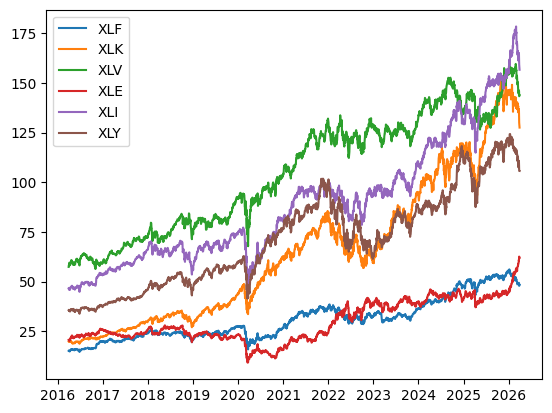

In [53]:
#visualizzo head di ogni ETF e un grafico con i prezzi di chiusura di tutti gli ETF

print('State Street Financial Select Sector SPDR ETF\n', XLF.head())
print('State Street Technology Select Sector SPDR ETF\n', XLK.head())
print('State Street Healthcare Select Sector SPDR ETF\n', XLV.head())
print('State Street Energy Select Sector SPDR ETF\n', XLE.head())
print('State Street Industrials Select Sector SPDR ETF\n', XLI.head())
print('State Street Consumer Discretionary Select Sector SPDR ETF\n', XLY.head())

plt.plot(XLF['Close'], label='XLF')
plt.plot(XLK['Close'], label='XLK')
plt.plot(XLV['Close'], label='XLV')
plt.plot(XLE['Close'], label='XLE')
plt.plot(XLI['Close'], label='XLI')
plt.plot(XLY['Close'], label='XLY')
plt.legend()

In [54]:
##PUNTO 2
#calcolo i rendimenti cumulati e composti annui


prezzi_chiusura = data['Close']

rend_cumulato = (prezzi_chiusura.iloc[-1] / prezzi_chiusura.iloc[0]) - 1

cagr = (prezzi_chiusura.iloc[-1] / prezzi_chiusura.iloc[0])**(1/10) - 1

performance = pd.DataFrame({
    'Rendimento Cumulato': rend_cumulato,
    'Rendimento Composto Annuo': cagr
})

print(performance)


        Rendimento Cumulato  Rendimento Composto Annuo
Ticker                                                
XLE                2.003655                   0.116259
XLF                2.189666                   0.122986
XLI                2.363597                   0.128965
XLK                5.409274                   0.204151
XLV                1.507538                   0.096288
XLY                1.968890                   0.114960
SP500              2.079865                   0.119059


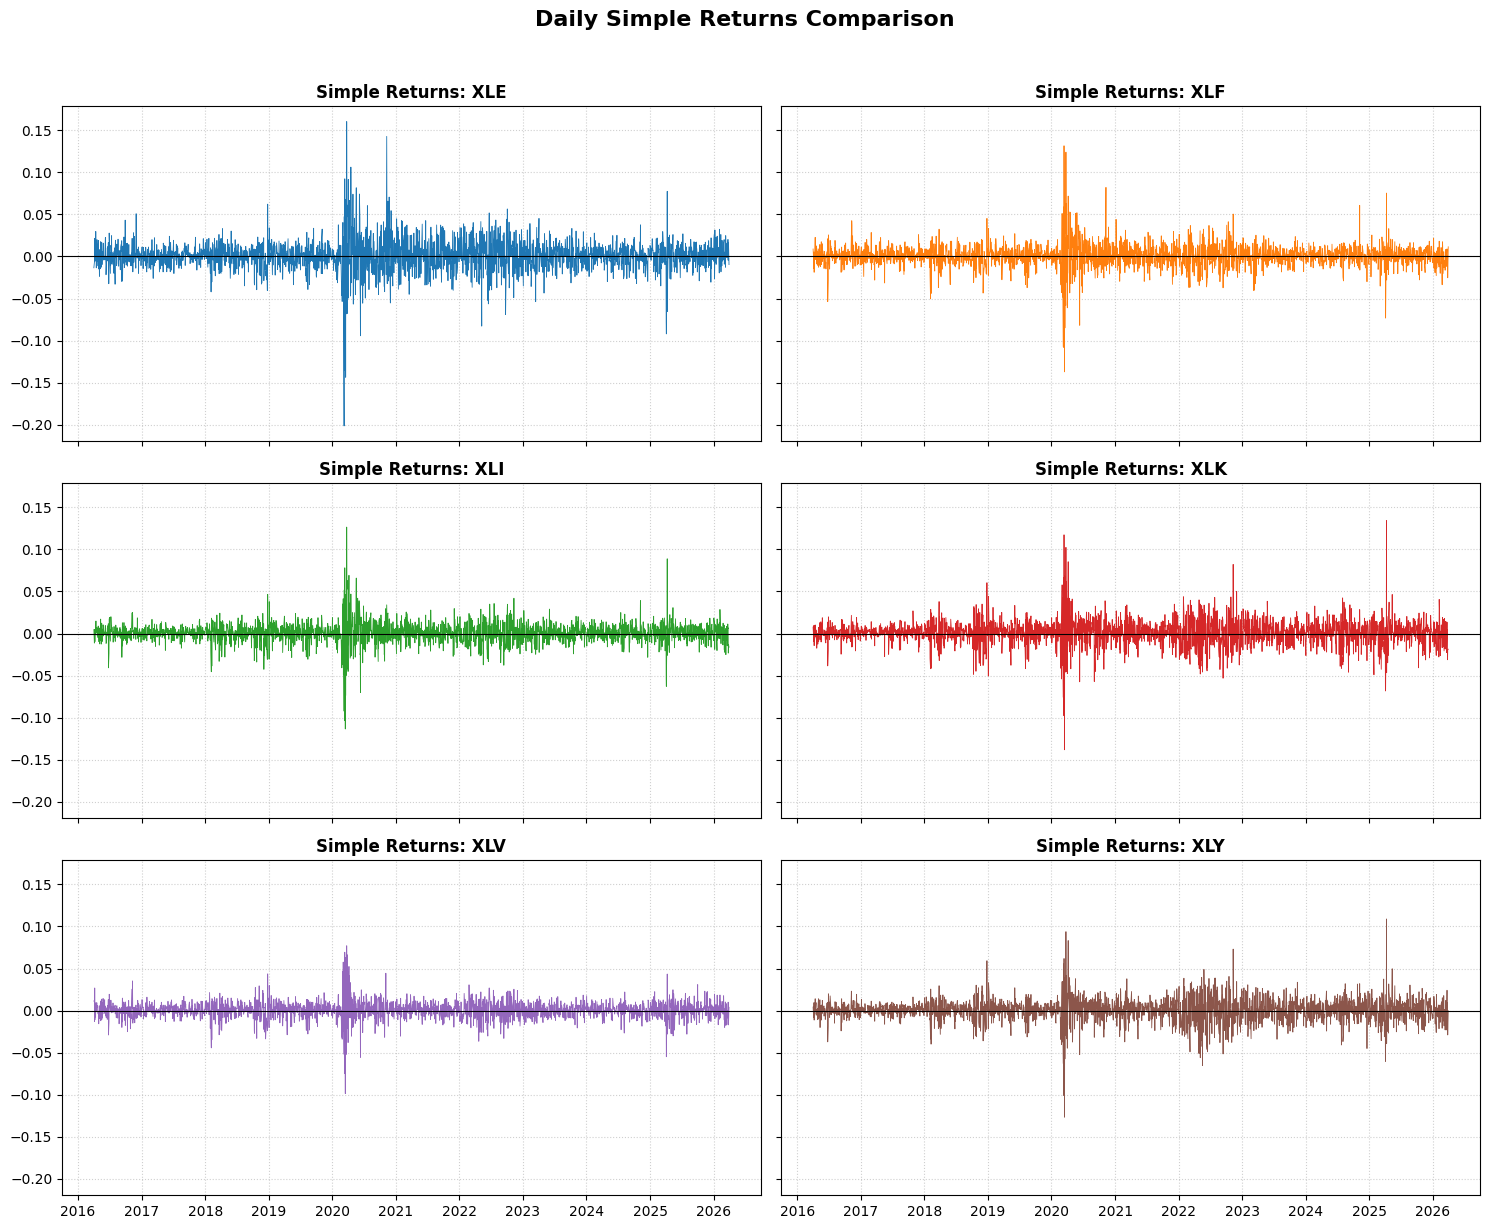

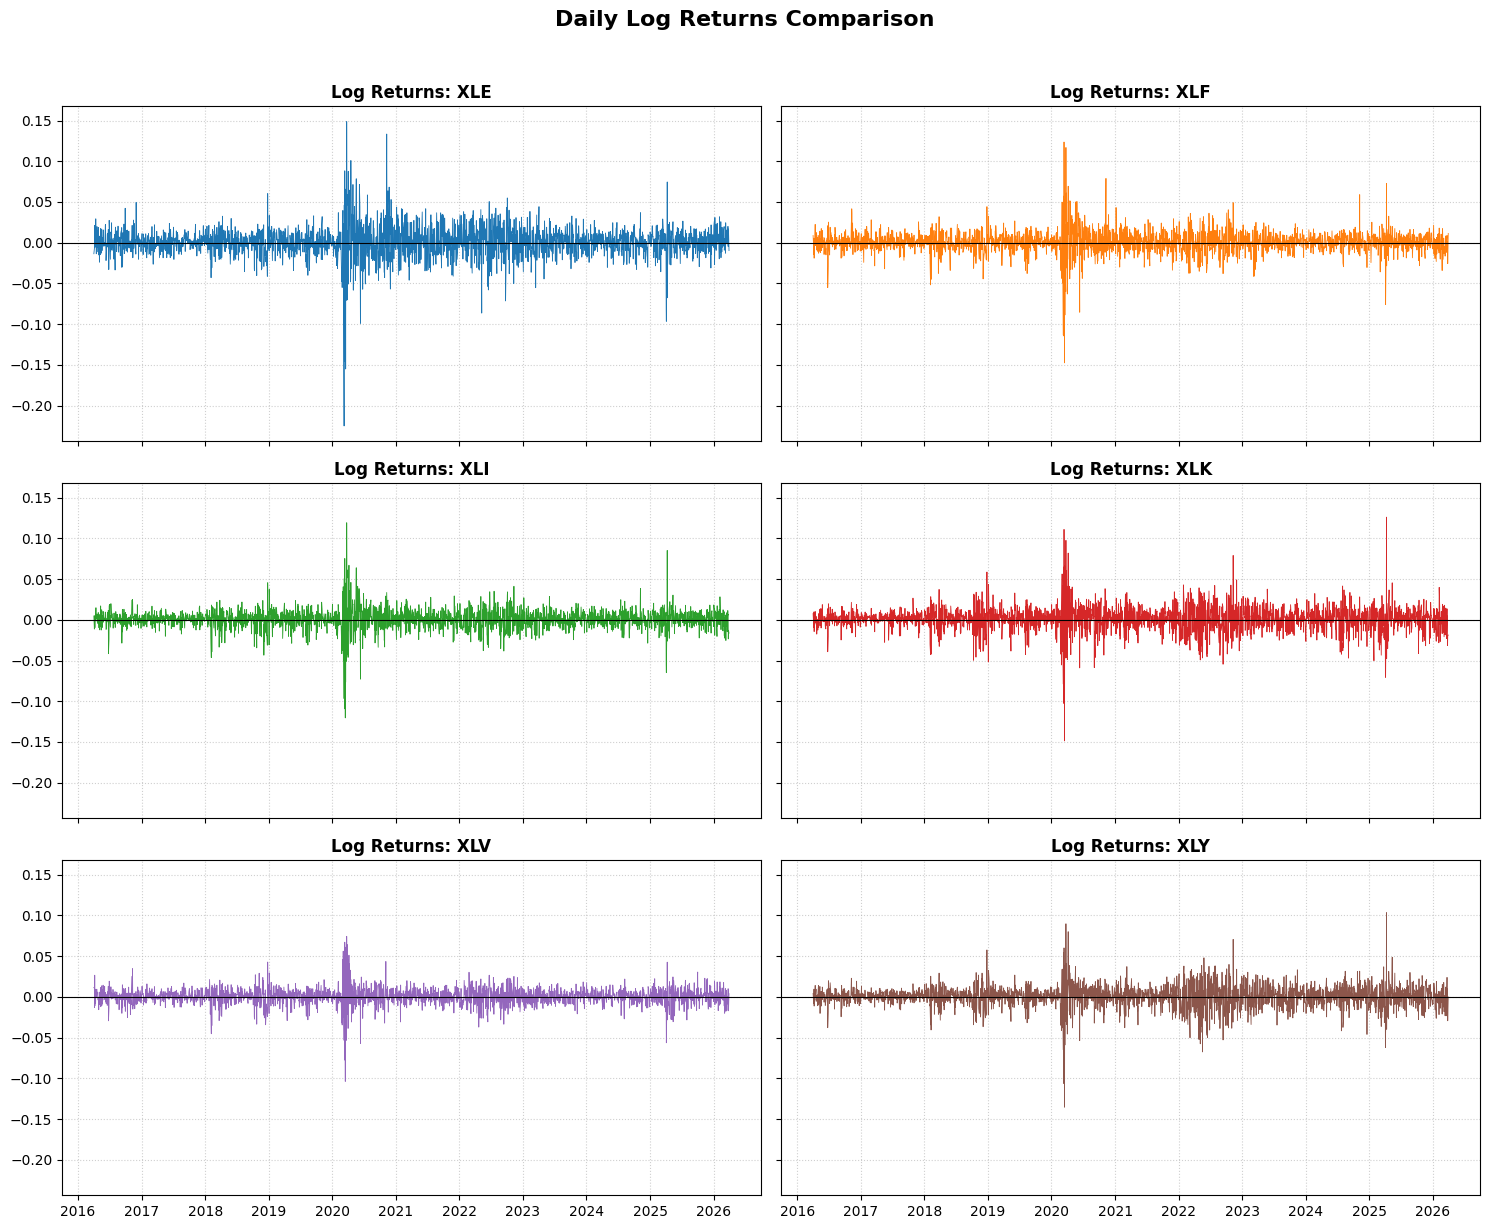

In [56]:
#Calcolo dei rendimenti semplici e logaritmici

simple_returns = prezzi_chiusura.pct_change().dropna()

log_returns = np.log(prezzi_chiusura / prezzi_chiusura.shift(1)).dropna()


tickers = simple_returns.columns
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig1, axes1 = plt.subplots(nrows=3, ncols=2, figsize=(15, 12), sharex=True, sharey=True)
axes1 = axes1.flatten()

for i, ticker in enumerate(tickers):
    if ticker != 'SP500':
        axes1[i].plot(simple_returns.index, simple_returns[ticker], color=colors[i], lw=0.6)
        axes1[i].set_title(f'Simple Returns: {ticker}', fontweight='bold')
        axes1[i].axhline(0, color='black', lw=0.8)
        axes1[i].grid(True, linestyle=':', alpha=0.6)

fig1.suptitle('Daily Simple Returns Comparison', fontsize=16, fontweight='bold', y=1.02)
fig1.tight_layout()



fig2, axes2 = plt.subplots(nrows=3, ncols=2, figsize=(15, 12), sharex=True, sharey=True)
axes2 = axes2.flatten()

for i, ticker in enumerate(tickers):
    if ticker != 'SP500':
        axes2[i].plot(log_returns.index, log_returns[ticker], color=colors[i], lw=0.6)
        axes2[i].set_title(f'Log Returns: {ticker}', fontweight='bold')
        axes2[i].axhline(0, color='black', lw=0.8)
        axes2[i].grid(True, linestyle=':', alpha=0.6)

fig2.suptitle('Daily Log Returns Comparison', fontsize=16, fontweight='bold', y=1.02)
fig2.tight_layout()

plt.show()

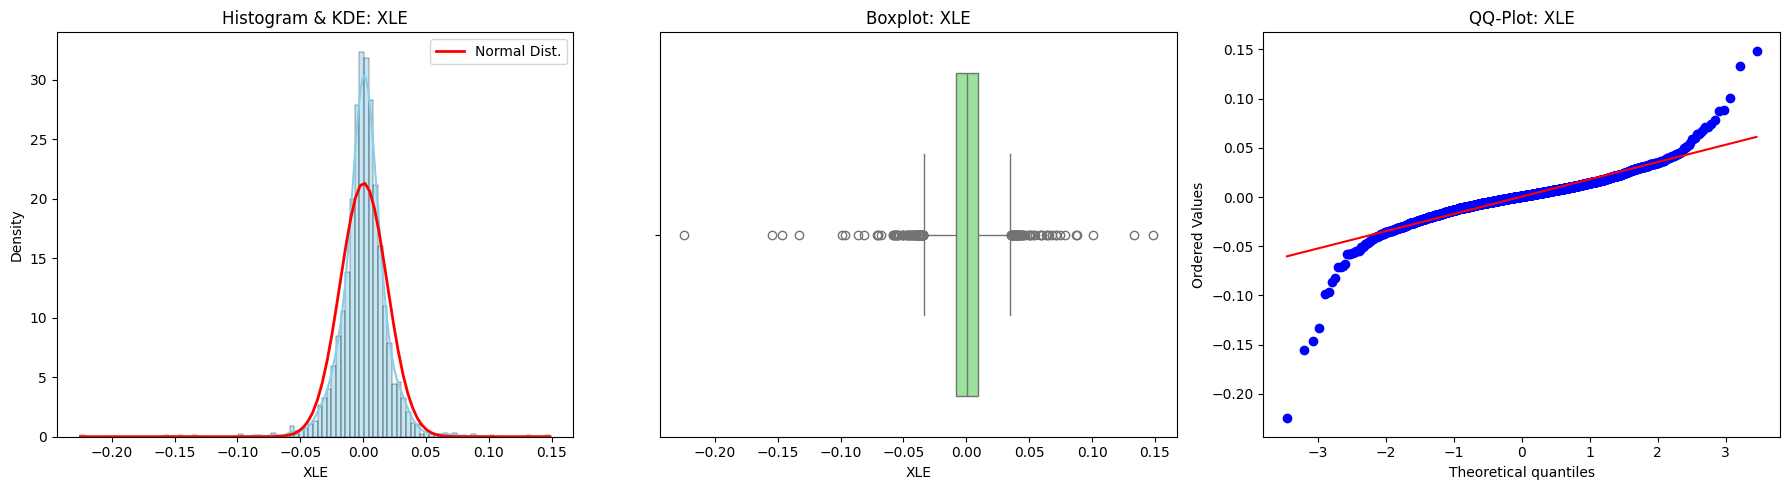

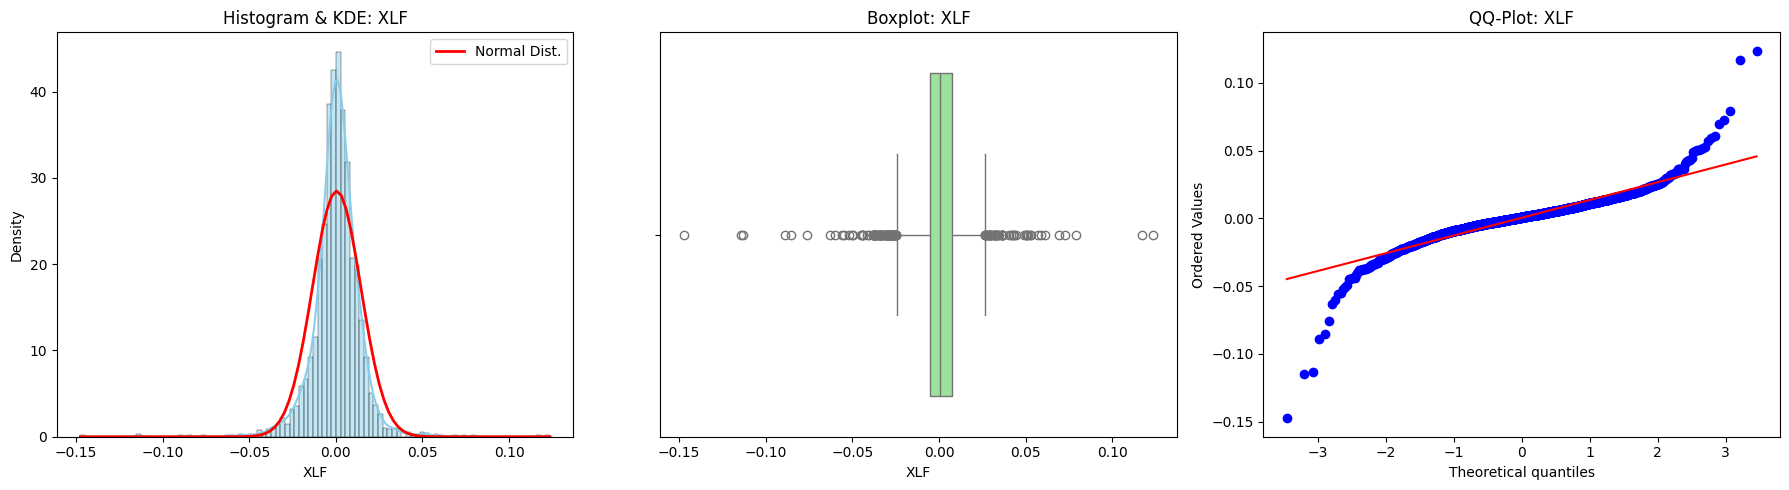

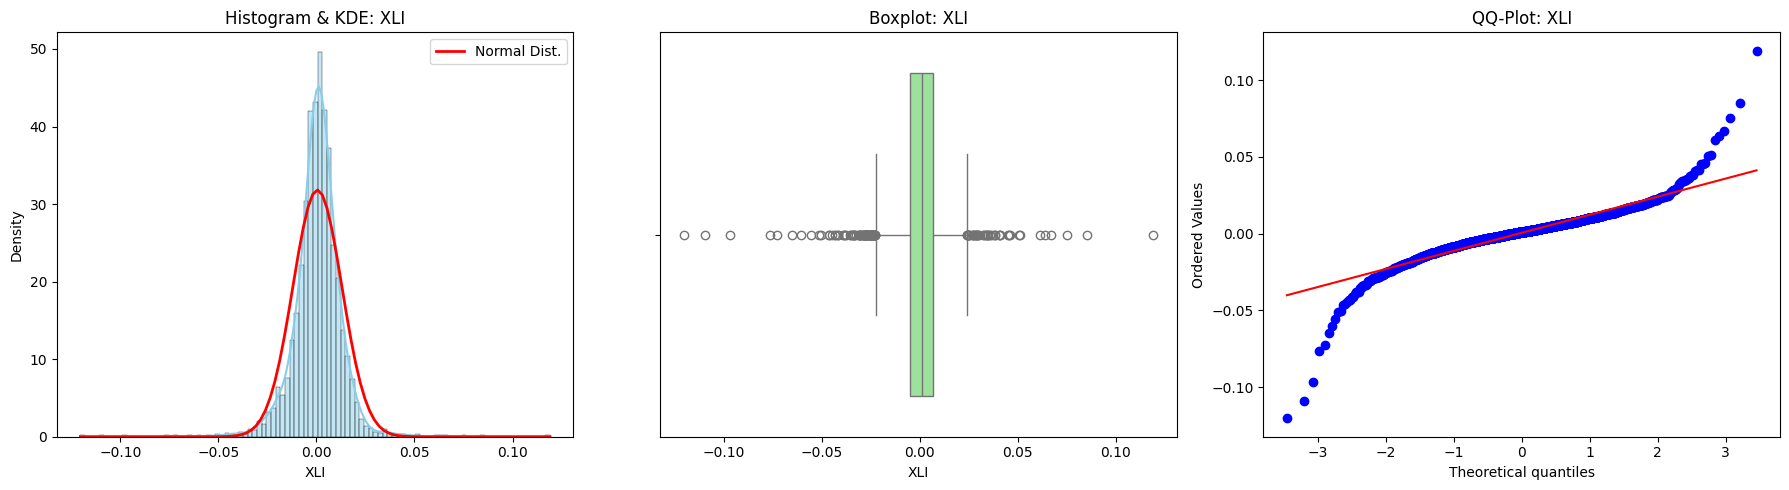

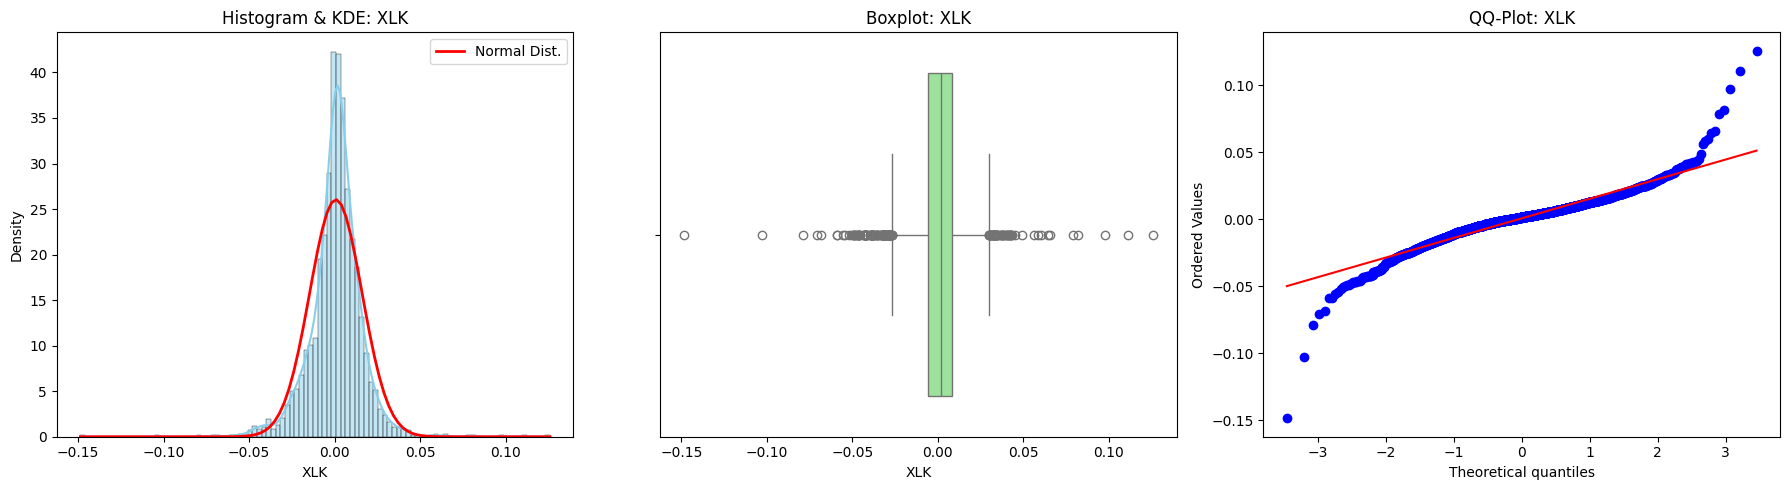

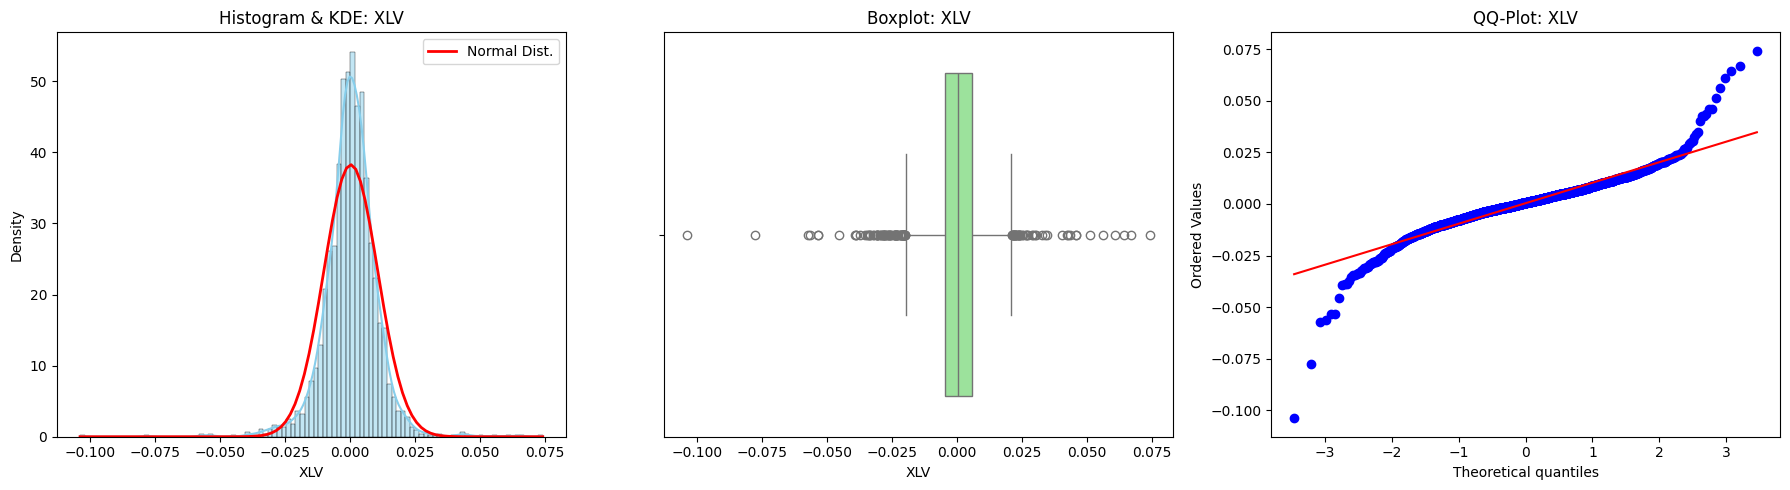

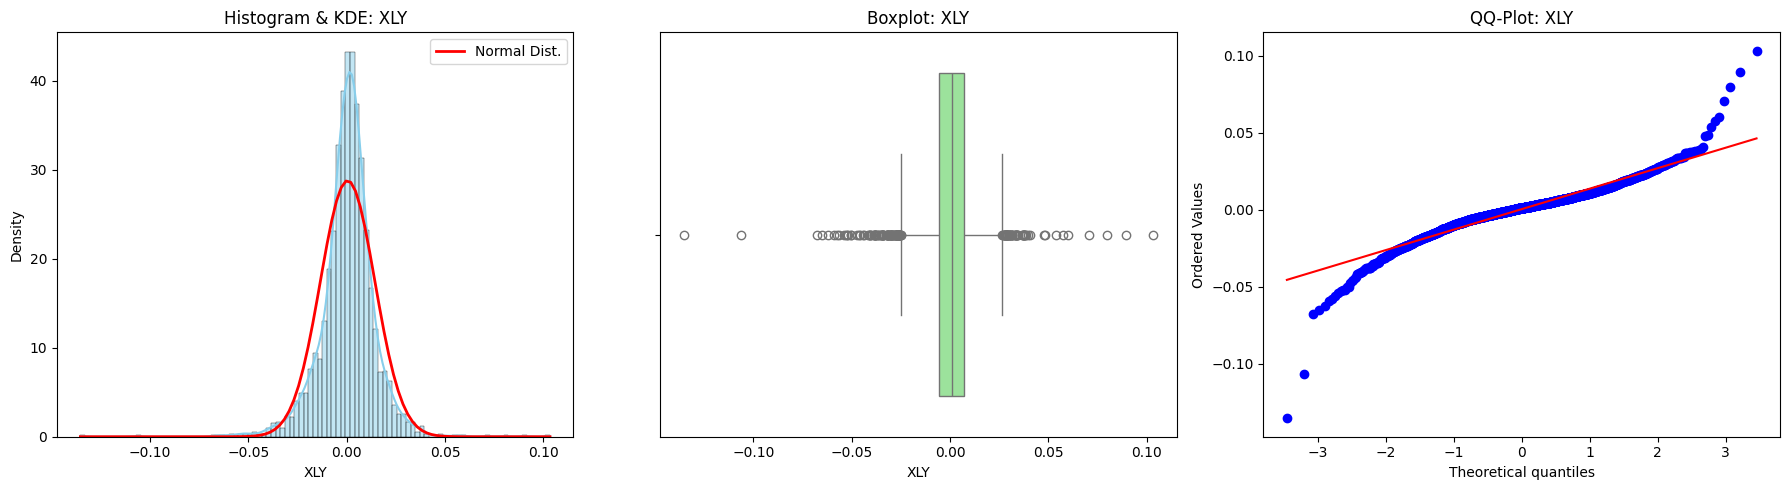

In [58]:
#Grafici diagnostici (istogrammi, boxplot e qqplot)

for ticker in log_returns.columns:
    if ticker != 'SP500':
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        data = log_returns[ticker]
    
        sns.histplot(data, kde=True, ax=axes[0], color='skyblue', stat="density")
        mu, std = data.mean(), data.std()
        x = np.linspace(data.min(), data.max(), 100)
        p = stats.norm.pdf(x, mu, std)
        axes[0].plot(x, p, 'r', linewidth=2, label='Normal Dist.')
        axes[0].set_title(f'Histogram & KDE: {ticker}')
        axes[0].legend()
    
        sns.boxplot(x=data, ax=axes[1], color='lightgreen')
        axes[1].set_title(f'Boxplot: {ticker}')
    
        stats.probplot(data, dist="norm", plot=axes[2])
        axes[2].set_title(f'QQ-Plot: {ticker}')
    
        plt.tight_layout()
        plt.show()

In [59]:
#Statistiche descrittive annualizzate

stats_df = pd.DataFrame()

stats_df['Media Ann. (%)'] = log_returns.mean() * 252 * 100
stats_df['Volatilità Ann. (%)'] = log_returns.std() * np.sqrt(252) * 100
stats_df['Varianza Ann.'] = log_returns.var() * 252
stats_df['Asimmetria (Skewness)'] = log_returns.skew()
stats_df['Curtosi (Kurtosis)'] = log_returns.kurtosis()

print("--- Statistiche Descrittive Annualizzate (2016-2026) ---")
print(stats_df.round(3))

--- Statistiche Descrittive Annualizzate (2016-2026) ---
        Media Ann. (%)  Volatilità Ann. (%)  Varianza Ann.  \
Ticker                                                       
XLE             11.029               29.681          0.088   
XLF             11.631               22.241          0.049   
XLI             12.164               19.903          0.040   
XLK             18.629               24.317          0.059   
XLV              9.219               16.549          0.027   
XLY             10.912               22.015          0.048   
SP500           11.280               18.076          0.033   

        Asimmetria (Skewness)  Curtosi (Kurtosis)  
Ticker                                             
XLE                    -0.966              17.129  
XLF                    -0.603              15.869  
XLI                    -0.570              14.356  
XLK                    -0.312               9.711  
XLV                    -0.426              10.319  
XLY                 

--- Matrice di Varianza/Covarianza Annualizzata ---
Ticker       XLE       XLF       XLI       XLK       XLV       XLY     SP500
Ticker                                                                      
XLE     0.007504  0.003269  0.002910  0.001550  0.001469  0.002136  0.002129
XLF     0.003269  0.003167  0.002594  0.001834  0.001387  0.002239  0.002033
XLI     0.002910  0.002594  0.002989  0.002148  0.001542  0.002444  0.002153
XLK     0.001550  0.001834  0.002148  0.003097  0.001225  0.002690  0.002187
XLV     0.001469  0.001387  0.001542  0.001225  0.001762  0.001359  0.001343
XLY     0.002136  0.002239  0.002444  0.002690  0.001359  0.003364  0.002282
SP500   0.002129  0.002033  0.002153  0.002187  0.001343  0.002282  0.001923
--- Matrice di Correlazione (Mensile) ---
Ticker    XLE    XLF    XLI    XLK    XLV    XLY  SP500
Ticker                                                 
XLE     1.000  0.671  0.614  0.322  0.404  0.425  0.561
XLF     0.671  1.000  0.843  0.586  0.587  0.

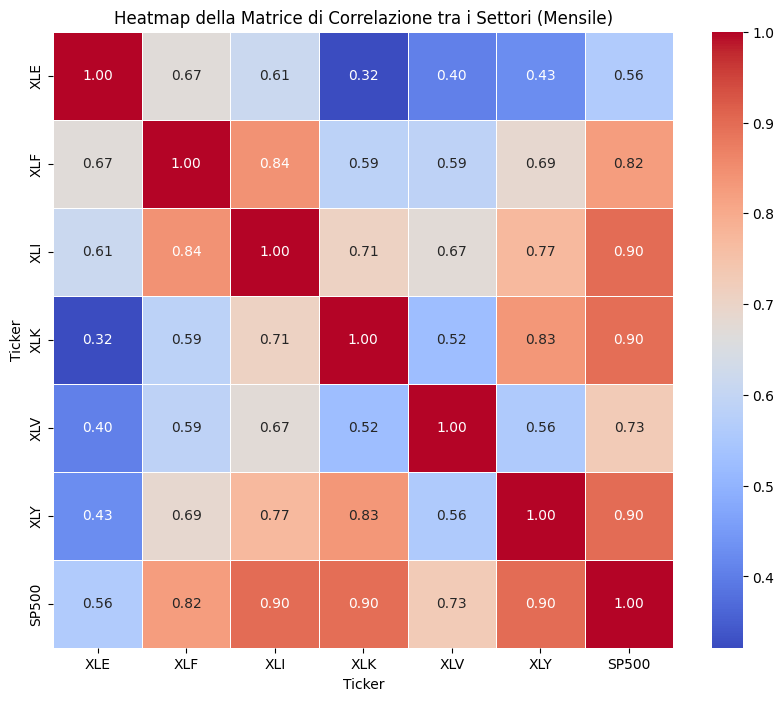

In [60]:
#Matrice di varianza-covarianza e di correlazione dei rendimenti mensili

log_returns_monthly = log_returns.resample('ME').sum()

cov_matrix = log_returns_monthly.cov()

cor_matrix = log_returns_monthly.corr()

print("--- Matrice di Varianza/Covarianza Annualizzata ---")
print(cov_matrix.round(6))

print("--- Matrice di Correlazione (Mensile) ---")
print(cor_matrix.round(3))


plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap della Matrice di Correlazione tra i Settori (Mensile)')
plt.show()

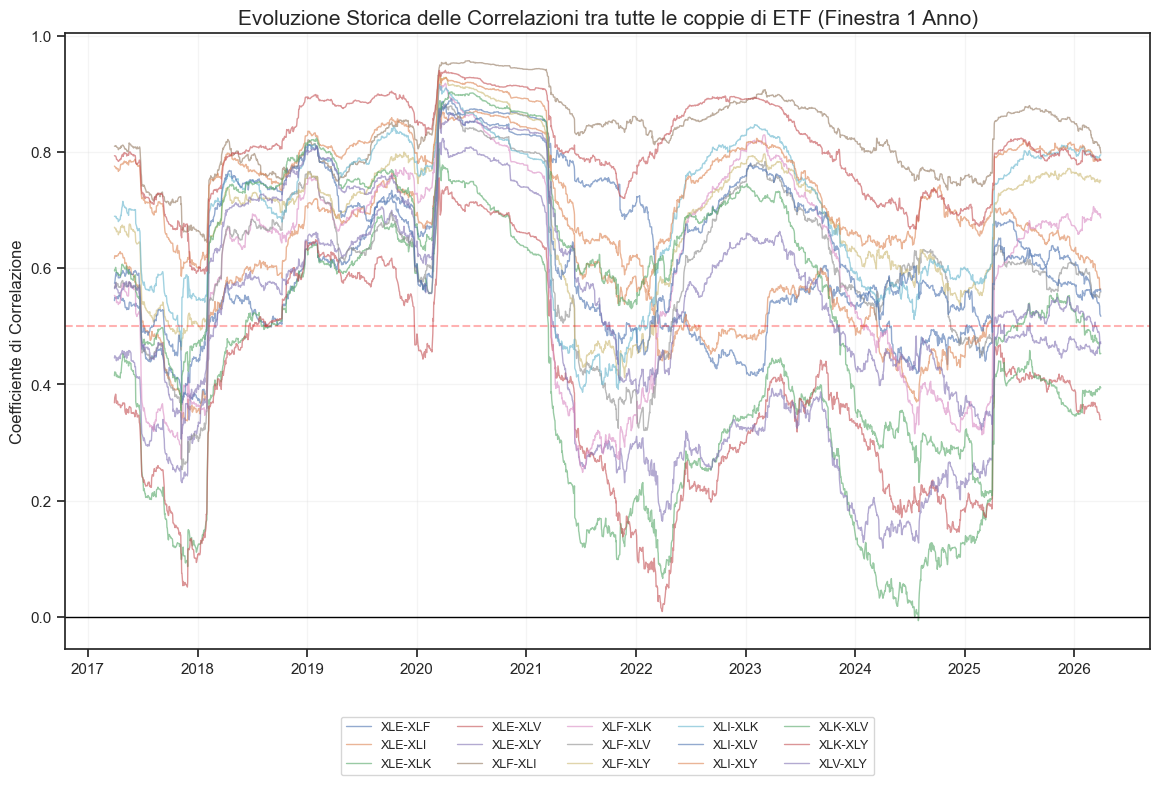

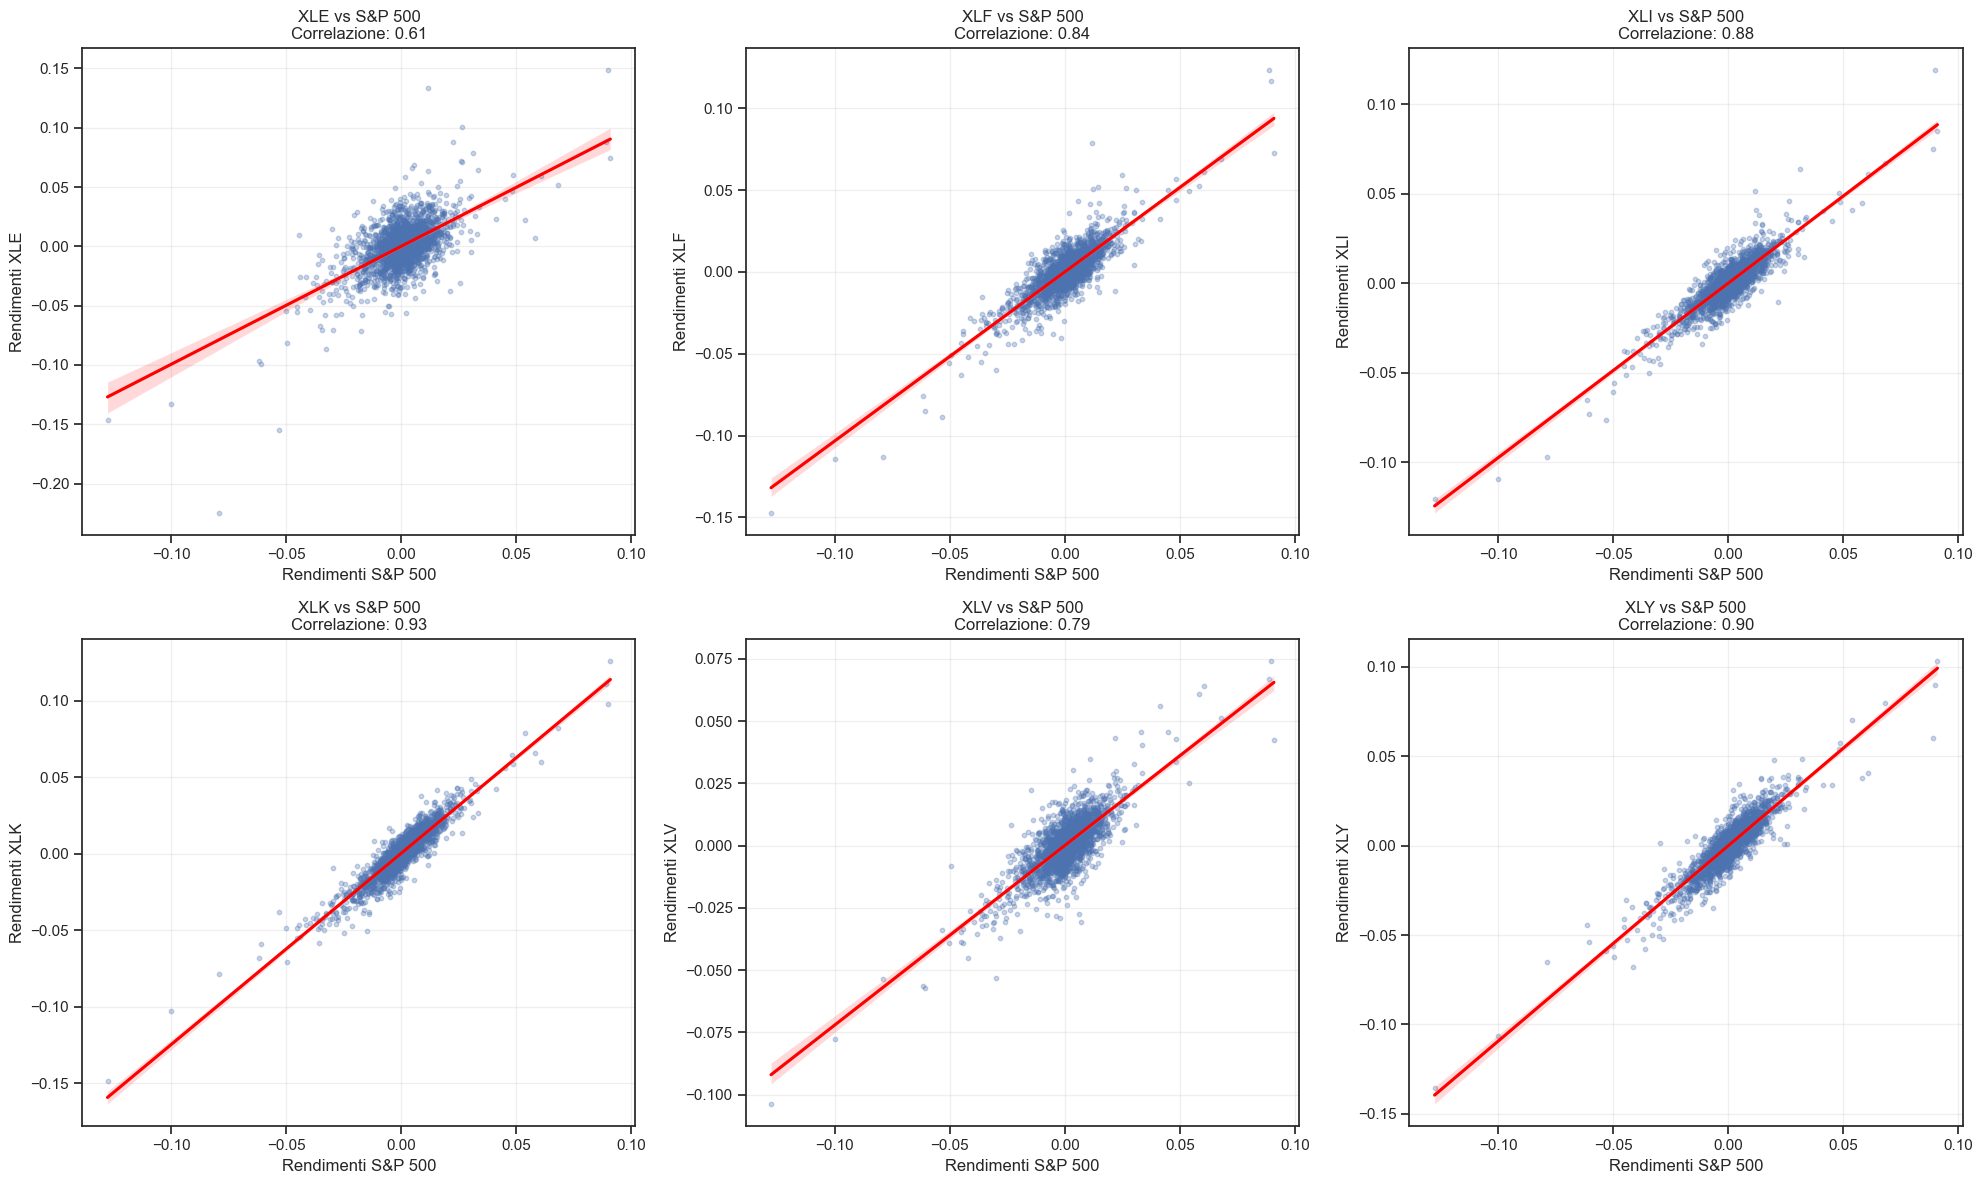

In [66]:
#Grafico dell'andamento nel tempo delle correlazioni e grafico dei rendimenti degli ETF con l'indice

import itertools

etf_columns = [col for col in log_returns.columns if col != 'SP500']
coppie = list(itertools.combinations(etf_columns, 2))

plt.figure(figsize=(14, 8))

for c1, c2 in coppie:
    rolling_corr_pair = log_returns[c1].rolling(window=252).corr(log_returns[c2])
    plt.plot(rolling_corr_pair, label=f'{c1}-{c2}', alpha=0.6, lw=1)

plt.title('Evoluzione Storica delle Correlazioni tra tutte le coppie di ETF (Finestra 1 Anno)', fontsize=15)
plt.axhline(0, color='black', lw=1)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.3) # Riferimento correlazione moderata
plt.ylabel('Coefficiente di Correlazione')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=9)
plt.grid(True, alpha=0.2)
plt.show()


mercato = 'SP500'
etfs = [t for t in tickers if t != mercato]
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, etf in enumerate(etfs):
    sns.regplot(x=log_returns[mercato], y=log_returns[etf], ax=axes[i],
                scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    
    # Calcolo della correlazione puntuale per il titolo
    corr_val = log_returns[mercato].corr(log_returns[etf])
    
    axes[i].set_title(f'{etf} vs S&P 500\nCorrelazione: {corr_val:.2f}')
    axes[i].set_xlabel('Rendimenti S&P 500')
    axes[i].set_ylabel(f'Rendimenti {etf}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()